## Research Question

"Does diabetes prevalence predict Medicare spending, and where does actual spending diverge from what disease burden would predict?"

## Data Sources

Two data sources: PLACES (provides county-level diabetes prevalence estimates), 
CMS (provides county-level standardized per-capita Medicare spending and beneficiary counts)

Scope: County-level data, 2023, continental US

## Key Terms
Money Pit: the 10 counties per tier where actual spending exceeds what diabetes prevalence predicts by a wide margin

Underserved: the 10 counties per tier where actual spending is less than what diabetes prevalence predicts by a wide margin

In [61]:
import pandas as pd
%pip install tabulate
# Load PLACES (Source A)
df = pd.read_csv("PLACES__County_Data_(GIS_Friendly_Format),_2025_release_20260723.csv", dtype={"CountyFIPS": str})

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Clean PLACES
# Keep rows with a real diabetes value
# Trim to only necessary columns going forward
places_clean = df[ df['DIABETES_AdjPrev'].notna()][['CountyFIPS', 'CountyName', 'StateAbbr', 'DIABETES_AdjPrev']]

In [3]:
# Load CMS (Source B)
# Force BENE_GEO_CD to load as string
cms = pd.read_csv("2014-2024 Original Medicare Geographic Variation Public Use File.csv", dtype={"BENE_GEO_CD": str})

/var/folders/0h/pnmv5mvd39gg0kf3zqwj1g200000gn/T/ipykernel_15788/2694738827.py:3: DtypeWarning: Columns (0: TOT_PBPMT_RDCTN_AMT, 1: TOT_PBPMT_RDCTN_PCC) have mixed types. Specify dtype option on import or set low_memory=False.
  cms = pd.read_csv("2014-2024 Original Medicare Geographic Variation Public Use File.csv", dtype={"BENE_GEO_CD": str})


In [4]:
# Explore columns before narrowing down
cms.columns

Index(['YEAR', 'BENE_GEO_LVL', 'BENE_GEO_DESC', 'BENE_GEO_CD', 'BENE_AGE_LVL',
       'BENES_TOTAL_CNT', 'BENES_WTH_PTAPTB_CNT', 'BENES_OM_CNT',
       'BENES_MA_CNT', 'MA_PRTCPTN_RATE',
       ...
       'PQI11_BCTRL_PNA_AGE_LT_65', 'PQI11_BCTRL_PNA_AGE_65_74',
       'PQI11_BCTRL_PNA_AGE_GE_75', 'PQI12_UTI_AGE_LT_65',
       'PQI12_UTI_AGE_65_74', 'PQI12_UTI_AGE_GE_75', 'PQI15_ASTHMA_AGE_LT_40',
       'PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65', 'PQI16_LWRXTRMTY_AMPUTN_AGE_65_74',
       'PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75'],
      dtype='str', length=246)

In [5]:
# Clean CMS 
# Filter to just 2023, County-level rows
cms_clean = cms[ (cms['YEAR'] == 2023) & (cms['BENE_GEO_LVL'] == 'County')]

In [6]:
# Trim to just columns needed
cms_clean = cms_clean[['BENE_GEO_CD', 'BENE_GEO_DESC', 'TOT_MDCR_STDZD_PYMT_PC', 'BENES_OM_CNT']]

In [7]:
# Remove "-UNKNOWN" placeholder rows
cms_clean = cms_clean[~cms_clean['BENE_GEO_DESC'].str.contains('-UNKNOWN')]


In [8]:
# Convert spending column from text to real numbers,
# turn any leftover suppressed '*' values into NaN
cms_clean['TOT_MDCR_STDZD_PYMT_PC'] = pd.to_numeric(cms_clean['TOT_MDCR_STDZD_PYMT_PC'], errors='coerce')

In [9]:
cms_clean['BENES_OM_CNT'] = pd.to_numeric(cms_clean['BENES_OM_CNT'], errors='coerce')

In [10]:
places_clean['CountyFIPS'].duplicated().sum()
cms_clean['BENE_GEO_CD'].duplicated().sum()

np.int64(0)

Before merging, checking join-key uniqueness and match rate to catch silent data loss.

In [11]:
audit = pd.merge(places_clean, cms_clean, left_on='CountyFIPS', right_on='BENE_GEO_CD', how='outer', indicator=True)
audit['_merge'].value_counts()

_merge
both          2955
right_only     191
left_only        1
Name: count, dtype: int64

In [12]:
right_only = audit[audit['_merge'] == 'right_only']
right_only['BENE_GEO_DESC'].str.split('-').str[0].value_counts()

BENE_GEO_DESC
KY    120
PA     67
VI      3
TX      1
Name: count, dtype: int64

KY + PA = 187 which matches the gap number known previously. VI is a US territory and it is likely that PLACES doesn't cover these types of US territories. 

Closer look at the Texas county below

In [13]:
right_only[right_only['BENE_GEO_DESC'].str.startswith('TX')]

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,_merge
2675,NaN,NaN,NaN,NaN,48301,TX-Loving,21062.61,11.0,right_only


In [14]:
# Merge
result = pd.merge(places_clean, cms_clean, left_on ='CountyFIPS', right_on='BENE_GEO_CD', how='inner')

In [15]:
# Save
result.to_csv("merged_diabetes_spending_2023_v2.csv", index=False)

In [16]:
result.shape

(2955, 8)

In [17]:

result = result[ result['TOT_MDCR_STDZD_PYMT_PC'].notna()]

In [18]:
result.shape

(2954, 8)

In [19]:
result.to_csv("merged_diabetes_spending_2023_v2.csv", index=False)

In [20]:
#Re-run summary stats on final clean data
result['TOT_MDCR_STDZD_PYMT_PC'].describe()

count     2954.000000
mean     11659.375430
std       1925.379164
min       5332.910000
25%      10424.077500
50%      11486.815000
75%      12696.672500
max      27129.010000
Name: TOT_MDCR_STDZD_PYMT_PC, dtype: float64

In [21]:
#Re-run summary stats on final clean data
result['DIABETES_AdjPrev'].describe()

count    2954.000000
mean       11.168517
std         2.330118
min         6.000000
25%         9.500000
50%        10.700000
75%        12.500000
max        23.800000
Name: DIABETES_AdjPrev, dtype: float64

In [22]:
#scatterplot, import matplotlib
import matplotlib.pyplot as plt


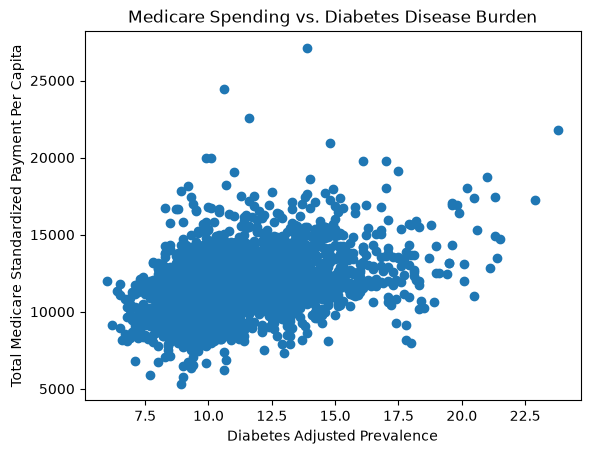

In [23]:
plt.scatter(result['DIABETES_AdjPrev'], result['TOT_MDCR_STDZD_PYMT_PC'])
plt.xlabel('Diabetes Adjusted Prevalence')
plt.ylabel('Total Medicare Standardized Payment Per Capita')
plt.title('Medicare Spending vs. Diabetes Disease Burden')
plt.show()

In [24]:
result['DIABETES_AdjPrev'].corr(result['TOT_MDCR_STDZD_PYMT_PC'])

np.float64(0.41582504441758855)

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

X = result[['DIABETES_AdjPrev']]   # diabetes column
y = result['TOT_MDCR_STDZD_PYMT_PC']     # spending column

In [26]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[343.6]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['DIABETES_AdjPrev']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7822
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [27]:
model.coef_

array([343.59663869])

In [28]:
model.intercept_

np.float64(7821.910438646597)

In [29]:
result['predicted_spending'] = model.predict(X)

In [30]:
result.head()

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending
0,40061,Haskell,OK,12.4,40061,OK-Haskell,14150.26,1851.0,12082.508758
1,17097,Lake,IL,9.8,17097,IL-Lake,12394.39,71683.0,11189.157498
2,20005,Atchison,KS,10.0,20005,KS-Atchison,11722.11,2325.0,11257.876826
3,02020,Anchorage,AK,8.8,02020,AK-Anchorage,9192.93,37223.0,10845.560859
4,40133,Seminole,OK,13.7,40133,OK-Seminole,14770.81,2784.0,12529.184389


In [31]:
result['residual'] = result['TOT_MDCR_STDZD_PYMT_PC'] - result['predicted_spending']

In [32]:
result['residual'].describe()

count    2.954000e+03
mean     1.961848e-12
std      1.751026e+03
min     -6.046490e+03
25%     -1.117030e+03
50%     -1.595572e+02
75%      1.002717e+03
max      1.453111e+04
Name: residual, dtype: float64

In [33]:
result.head()

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual
0,40061,Haskell,OK,12.4,40061,OK-Haskell,14150.26,1851.0,12082.508758,2067.751242
1,17097,Lake,IL,9.8,17097,IL-Lake,12394.39,71683.0,11189.157498,1205.232502
2,20005,Atchison,KS,10.0,20005,KS-Atchison,11722.11,2325.0,11257.876826,464.233174
3,02020,Anchorage,AK,8.8,02020,AK-Anchorage,9192.93,37223.0,10845.560859,-1652.630859
4,40133,Seminole,OK,13.7,40133,OK-Seminole,14770.81,2784.0,12529.184389,2241.625611


In [34]:
result.sort_values(by='residual', ascending=False).head(10)

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual
1101,13201,Miller,GA,13.9,13201,GA-Miller,27129.01,620.0,12597.903716,14531.106284
1987,20075,Hamilton,KS,10.6,20075,KS-Hamilton,24463.43,354.0,11464.034809,12999.395191
2116,40055,Greer,OK,11.6,40055,OK-Greer,22580.43,895.0,11807.631447,10772.798553
805,20135,Ness,KS,9.9,20135,KS-Ness,19985.99,708.0,11223.517162,8762.472838
2832,20185,Stafford,KS,10.1,20185,KS-Stafford,19970.14,832.0,11292.236489,8677.903511
2864,48461,Upton,TX,14.8,48461,TX-Upton,20974.96,303.0,12907.140691,8067.819309
2347,02185,North Slope,AK,11.0,02185,AK-North Slope,19064.37,459.0,11601.473464,7462.896536
1317,20063,Gove,KS,9.2,20063,KS-Gove,18183.61,608.0,10982.999515,7200.610485
1620,20179,Sheridan,KS,8.9,20179,KS-Sheridan,17848.40,581.0,10879.920523,6968.479477
426,20089,Jewell,KS,10.7,20089,KS-Jewell,18198.27,772.0,11498.394473,6699.875527


In [35]:
result.sort_values(by='residual', ascending=True).head(10)

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual
2885,02158,Kusilvak,AK,18.0,02158,AK-Kusilvak,7960.16,513.0,14006.649935,-6046.489935
235,48377,Presidio,TX,17.8,48377,TX-Presidio,8197.14,854.0,13937.930607,-5740.790607
1286,02066,Copper River,AK,8.9,02066,AK-Copper River,5332.91,178.0,10879.920523,-5547.010523
2083,02282,Yakutat,AK,10.6,02282,AK-Yakutat,6204.57,96.0,11464.034809,-5259.464809
657,30045,Judith Basin,MT,9.0,30045,MT-Judith Basin,5753.52,382.0,10914.280187,-5160.760187
2782,35057,Torrance,NM,13.0,35057,NM-Torrance,7323.63,1133.0,12288.666742,-4965.036742
372,28055,Issaquena,MS,17.8,28055,MS-Issaquena,9124.59,135.0,13937.930607,-4813.340607
849,02050,Bethel,AK,14.7,02050,AK-Bethel,8116.22,1390.0,12872.781027,-4756.561027
2183,31005,Arthur,NE,9.3,31005,NE-Arthur,6330.61,89.0,11017.359178,-4686.749178
2592,08109,Saguache,CO,10.7,08109,CO-Saguache,6875.44,855.0,11498.394473,-4622.954473


In [36]:
result['BENES_OM_CNT'].describe()

count      2954.000000
mean       9029.188219
std       22054.071841
min          14.000000
25%        1424.500000
50%        3018.500000
75%        7506.000000
max      542792.000000
Name: BENES_OM_CNT, dtype: float64

In [37]:
filtered = result[result['BENES_OM_CNT'] > 1424]
print(filtered.shape)
print(result.shape)

(2215, 10)
(2954, 10)


Exploring/testing three cutoffs

In [38]:
filtered.sort_values(by='residual', ascending=False).head(10)   # money pits


,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual
283,48399,Runnels,TX,11.8,48399,TX-Runnels,17482.01,1714.0,11876.350775,5605.659225
1036,22013,Bienville,LA,17.5,22013,LA-Bienville,19103.35,1602.0,13834.851616,5268.498384
1270,40015,Caddo,OK,13.9,40015,OK-Caddo,17631.68,3806.0,12597.903716,5033.776284
189,22117,Washington,LA,14.9,22117,LA-Washington,17953.84,4070.0,12941.500355,5012.339645
1891,20193,Thomas,KS,9.0,20193,KS-Thomas,15792.20,1432.0,10914.280187,4877.919813
1689,22059,LaSalle,LA,12.4,22059,LA-LaSalle,16930.52,1989.0,12082.508758,4848.011242
1882,40013,Bryan,OK,12.0,40013,OK-Bryan,16535.72,6181.0,11945.070103,4590.649897
2928,40117,Pawnee,OK,11.5,40117,OK-Pawnee,16271.49,2162.0,11773.271784,4498.218216
2882,48077,Clay,TX,9.8,48077,TX-Clay,15673.21,1684.0,11189.157498,4484.052502
473,48487,Wilbarger,TX,14.2,48487,TX-Wilbarger,17093.07,1504.0,12700.982708,4392.087292


In [39]:
filtered.sort_values(by='residual', ascending=True).head(10)    # underserved

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual
1896,16021,Boundary,ID,9.4,16021,ID-Boundary,6576.18,1991.0,11051.718842,-4475.538842
83,35039,Rio Arriba,NM,13.7,35039,NM-Rio Arriba,8198.28,4059.0,12529.184389,-4330.904389
1087,04023,Santa Cruz,AZ,13.2,04023,AZ-Santa Cruz,8441.27,3035.0,12357.386069,-3916.116069
1983,15001,Hawaii,HI,9.6,15001,HI-Hawaii,7473.46,21146.0,11120.438170,-3646.978170
1684,02090,Fairbanks North Star,AK,8.3,02090,AK-Fairbanks North Star,7065.32,11432.0,10673.762540,-3608.442540
2304,30035,Glacier,MT,14.5,30035,MT-Glacier,9261.80,1595.0,12804.061700,-3542.261700
965,15007,Kauai,HI,9.3,15007,HI-Kauai,7491.59,6844.0,11017.359178,-3525.769178
2479,35047,San Miguel,NM,13.3,35047,NM-San Miguel,8945.12,2974.0,12391.745733,-3446.625733
296,41035,Klamath,OR,11.2,41035,OR-Klamath,8264.66,10500.0,11670.192792,-3405.532792
672,41065,Wasco,OR,10.9,41065,OR-Wasco,8170.29,4152.0,11567.113800,-3396.823800


In [40]:
filtered_median = result[result['BENES_OM_CNT'] > 3018]
print(filtered_median.shape)


(1477, 10)


In [41]:
filtered_median.sort_values(by='residual', ascending=False).head(10)   # money pits

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual
1270,40015,Caddo,OK,13.9,40015,OK-Caddo,17631.68,3806.0,12597.903716,5033.776284
189,22117,Washington,LA,14.9,22117,LA-Washington,17953.84,4070.0,12941.500355,5012.339645
1882,40013,Bryan,OK,12.0,40013,OK-Bryan,16535.72,6181.0,11945.070103,4590.649897
2941,12086,Miami-Dade,FL,13.3,12086,FL-Miami-Dade,16635.80,92559.0,12391.745733,4244.054267
2478,48481,Wharton,TX,12.9,48481,TX-Wharton,16104.81,4379.0,12254.307078,3850.502922
1254,48485,Wichita,TX,11.6,48485,TX-Wichita,15559.90,15458.0,11807.631447,3752.268553
2403,48503,Young,TX,10.8,48503,TX-Young,15263.87,3110.0,11532.754136,3731.115864
1311,06037,Los Angeles,CA,11.6,06037,CA-Los Angeles,15515.30,542792.0,11807.631447,3707.668553
2916,48181,Grayson,TX,10.6,48181,TX-Grayson,15072.25,15228.0,11464.034809,3608.215191
1801,20149,Pottawatomie,KS,8.5,20149,KS-Pottawatomie,14304.59,3387.0,10742.481867,3562.108133


In [42]:
filtered_median.sort_values(by='residual', ascending=True).head(10)    # underserved

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual
83,35039,Rio Arriba,NM,13.7,35039,NM-Rio Arriba,8198.28,4059.0,12529.184389,-4330.904389
1087,04023,Santa Cruz,AZ,13.2,04023,AZ-Santa Cruz,8441.27,3035.0,12357.386069,-3916.116069
1983,15001,Hawaii,HI,9.6,15001,HI-Hawaii,7473.46,21146.0,11120.438170,-3646.978170
1684,02090,Fairbanks North Star,AK,8.3,02090,AK-Fairbanks North Star,7065.32,11432.0,10673.762540,-3608.442540
965,15007,Kauai,HI,9.3,15007,HI-Kauai,7491.59,6844.0,11017.359178,-3525.769178
296,41035,Klamath,OR,11.2,41035,OR-Klamath,8264.66,10500.0,11670.192792,-3405.532792
672,41065,Wasco,OR,10.9,41065,OR-Wasco,8170.29,4152.0,11567.113800,-3396.823800
1755,15009,Maui,HI,9.6,15009,HI-Maui,7870.07,10878.0,11120.438170,-3250.368170
2156,41019,Douglas,OR,10.5,41019,OR-Douglas,8215.28,16648.0,11429.675145,-3214.395145
2484,56033,Sheridan,WY,8.4,56033,WY-Sheridan,7494.69,7172.0,10708.122204,-3213.432204


In [43]:
filtered_75 = result[result['BENES_OM_CNT'] > 7506]
print(filtered_75.shape)


(739, 10)


In [44]:
filtered_75.sort_values(by='residual', ascending=False).head(10)   # money pits


,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual
2941,12086,Miami-Dade,FL,13.3,12086,FL-Miami-Dade,16635.80,92559.0,12391.745733,4244.054267
1254,48485,Wichita,TX,11.6,48485,TX-Wichita,15559.90,15458.0,11807.631447,3752.268553
1311,06037,Los Angeles,CA,11.6,06037,CA-Los Angeles,15515.30,542792.0,11807.631447,3707.668553
2916,48181,Grayson,TX,10.6,48181,TX-Grayson,15072.25,15228.0,11464.034809,3608.215191
2089,12011,Broward,FL,11.4,12011,FL-Broward,14971.76,98291.0,11738.912120,3232.847880
1271,12099,Palm Beach,FL,10.6,12099,FL-Palm Beach,14627.98,166189.0,11464.034809,3163.945191
2290,36103,Suffolk,NY,8.3,36103,NY-Suffolk,13816.63,197110.0,10673.762540,3142.867460
2662,12103,Pinellas,FL,9.8,12103,FL-Pinellas,14300.14,91025.0,11189.157498,3110.982502
709,12117,Seminole,FL,9.8,12117,FL-Seminole,14293.94,34877.0,11189.157498,3104.782502
1710,22015,Bossier,LA,12.1,22015,LA-Bossier,15080.88,12380.0,11979.429767,3101.450233


In [45]:
filtered_75.sort_values(by='residual', ascending=True).head(10)    # underserved

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual
1983,15001,Hawaii,HI,9.6,15001,HI-Hawaii,7473.46,21146.0,11120.438170,-3646.978170
1684,02090,Fairbanks North Star,AK,8.3,02090,AK-Fairbanks North Star,7065.32,11432.0,10673.762540,-3608.442540
296,41035,Klamath,OR,11.2,41035,OR-Klamath,8264.66,10500.0,11670.192792,-3405.532792
1755,15009,Maui,HI,9.6,15009,HI-Maui,7870.07,10878.0,11120.438170,-3250.368170
2156,41019,Douglas,OR,10.5,41019,OR-Douglas,8215.28,16648.0,11429.675145,-3214.395145
862,53065,Stevens,WA,9.1,53065,WA-Stevens,7870.06,8553.0,10948.639851,-3078.579851
2234,53077,Yakima,WA,12.1,53077,WA-Yakima,8919.76,23460.0,11979.429767,-3059.669767
1818,06023,Humboldt,CA,10.0,06023,CA-Humboldt,8256.17,25682.0,11257.876826,-3001.706826
2562,15003,Honolulu,HI,10.5,15003,HI-Honolulu,8580.86,63293.0,11429.675145,-2848.815145
724,06093,Siskiyou,CA,9.9,06093,CA-Siskiyou,8401.77,12545.0,11223.517162,-2821.747162


## Why total dollar impact, not just per-capita residual

Per-capita residual alone can mislead: Miami-Dade's per-capita overspend ($4,244) is actually higher than LA's ($3,708). However, LA has nearly 6x the beneficiaries, so its total dollar impact (~$2.0B) is about 5x Miami-Dade's (~$393M). This is why LA, not Miami-Dade, is called out in the annotated figure in the Supporting Tables and Figures section.

In [46]:
result['total_spending_diff'] = result['residual'] * result['BENES_OM_CNT']


result[result['BENE_GEO_DESC'].isin(['CA-Los Angeles', 'FL-Miami-Dade'])][
    ['BENE_GEO_DESC', 'BENES_OM_CNT', 'residual', 'total_spending_diff']
]

,BENE_GEO_DESC,BENES_OM_CNT,residual,total_spending_diff
1311,CA-Los Angeles,542792.0,3707.668553,2.012493e+09
2941,FL-Miami-Dade,92559.0,4244.054267,3.928254e+08


## Confidence

A handful of high-cost patients can balloon the per-capita number in a county with few beneficiaries, whereas the same handful of patients would barely change anything in a large county. Confidence tiers help illustrate how much weight to put on a given residual.


Confidence tiers built on quartiles of beneficiary count: 
Low confidence = bottom 25% (≤1,424 beneficiaries), 
Medium confidence = middle 50% (1,424–7,506 beneficiaries)
High confidence = top 25% (≥7,506 beneficiaries)



In [47]:
result['confidence'] = pd.cut(
    result['BENES_OM_CNT'],
    bins=[0, 1424, 7506, float('inf')],
    labels=['low', 'medium', 'high']
)

result['confidence'].value_counts()

confidence
medium    1476
low        739
high       739
Name: count, dtype: int64

In [48]:
high_conf = result[result['confidence'] == 'high']
high_conf.sort_values(by='residual', ascending=True).head(10)    # high-confidence underserved

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual,total_spending_diff,confidence
1983,15001,Hawaii,HI,9.6,15001,HI-Hawaii,7473.46,21146.0,11120.438170,-3646.978170,-7.711900e+07,high
1684,02090,Fairbanks North Star,AK,8.3,02090,AK-Fairbanks North Star,7065.32,11432.0,10673.762540,-3608.442540,-4.125172e+07,high
296,41035,Klamath,OR,11.2,41035,OR-Klamath,8264.66,10500.0,11670.192792,-3405.532792,-3.575809e+07,high
1755,15009,Maui,HI,9.6,15009,HI-Maui,7870.07,10878.0,11120.438170,-3250.368170,-3.535750e+07,high
2156,41019,Douglas,OR,10.5,41019,OR-Douglas,8215.28,16648.0,11429.675145,-3214.395145,-5.351325e+07,high
862,53065,Stevens,WA,9.1,53065,WA-Stevens,7870.06,8553.0,10948.639851,-3078.579851,-2.633109e+07,high
2234,53077,Yakima,WA,12.1,53077,WA-Yakima,8919.76,23460.0,11979.429767,-3059.669767,-7.177985e+07,high
1818,06023,Humboldt,CA,10.0,06023,CA-Humboldt,8256.17,25682.0,11257.876826,-3001.706826,-7.708983e+07,high
2562,15003,Honolulu,HI,10.5,15003,HI-Honolulu,8580.86,63293.0,11429.675145,-2848.815145,-1.803101e+08,high
724,06093,Siskiyou,CA,9.9,06093,CA-Siskiyou,8401.77,12545.0,11223.517162,-2821.747162,-3.539882e+07,high


In [49]:
high_conf.sort_values(by='residual', ascending=False).head(10)   # high-confidence money pits

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual,total_spending_diff,confidence
2941,12086,Miami-Dade,FL,13.3,12086,FL-Miami-Dade,16635.80,92559.0,12391.745733,4244.054267,3.928254e+08,high
1254,48485,Wichita,TX,11.6,48485,TX-Wichita,15559.90,15458.0,11807.631447,3752.268553,5.800257e+07,high
1311,06037,Los Angeles,CA,11.6,06037,CA-Los Angeles,15515.30,542792.0,11807.631447,3707.668553,2.012493e+09,high
2916,48181,Grayson,TX,10.6,48181,TX-Grayson,15072.25,15228.0,11464.034809,3608.215191,5.494590e+07,high
2089,12011,Broward,FL,11.4,12011,FL-Broward,14971.76,98291.0,11738.912120,3232.847880,3.177599e+08,high
1271,12099,Palm Beach,FL,10.6,12099,FL-Palm Beach,14627.98,166189.0,11464.034809,3163.945191,5.258129e+08,high
2290,36103,Suffolk,NY,8.3,36103,NY-Suffolk,13816.63,197110.0,10673.762540,3142.867460,6.194906e+08,high
2662,12103,Pinellas,FL,9.8,12103,FL-Pinellas,14300.14,91025.0,11189.157498,3110.982502,2.831772e+08,high
709,12117,Seminole,FL,9.8,12117,FL-Seminole,14293.94,34877.0,11189.157498,3104.782502,1.082855e+08,high
1710,22015,Bossier,LA,12.1,22015,LA-Bossier,15080.88,12380.0,11979.429767,3101.450233,3.839595e+07,high


In [50]:
medium_conf = result[result['confidence'] == 'medium']
medium_conf.sort_values(by='residual', ascending=True).head(10)    # medium-confidence underserved

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual,total_spending_diff,confidence
1896,16021,Boundary,ID,9.4,16021,ID-Boundary,6576.18,1991.0,11051.718842,-4475.538842,-8.910798e+06,medium
83,35039,Rio Arriba,NM,13.7,35039,NM-Rio Arriba,8198.28,4059.0,12529.184389,-4330.904389,-1.757914e+07,medium
1087,04023,Santa Cruz,AZ,13.2,04023,AZ-Santa Cruz,8441.27,3035.0,12357.386069,-3916.116069,-1.188541e+07,medium
2304,30035,Glacier,MT,14.5,30035,MT-Glacier,9261.80,1595.0,12804.061700,-3542.261700,-5.649907e+06,medium
965,15007,Kauai,HI,9.3,15007,HI-Kauai,7491.59,6844.0,11017.359178,-3525.769178,-2.413036e+07,medium
2479,35047,San Miguel,NM,13.3,35047,NM-San Miguel,8945.12,2974.0,12391.745733,-3446.625733,-1.025026e+07,medium
672,41065,Wasco,OR,10.9,41065,OR-Wasco,8170.29,4152.0,11567.113800,-3396.823800,-1.410361e+07,medium
1702,35007,Colfax,NM,11.4,35007,NM-Colfax,8402.96,2053.0,11738.912120,-3335.952120,-6.848710e+06,medium
870,05107,Phillips,AR,17.2,05107,AR-Phillips,10422.89,1688.0,13731.772624,-3308.882624,-5.585394e+06,medium
2274,54063,Monroe,WV,13.1,54063,WV-Monroe,9090.35,1986.0,12323.026405,-3232.676405,-6.420095e+06,medium


In [51]:
medium_conf.sort_values(by='residual', ascending=False).head(10)   # medium-confidence money pits

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual,total_spending_diff,confidence
283,48399,Runnels,TX,11.8,48399,TX-Runnels,17482.01,1714.0,11876.350775,5605.659225,9.608100e+06,medium
1036,22013,Bienville,LA,17.5,22013,LA-Bienville,19103.35,1602.0,13834.851616,5268.498384,8.440134e+06,medium
1270,40015,Caddo,OK,13.9,40015,OK-Caddo,17631.68,3806.0,12597.903716,5033.776284,1.915855e+07,medium
189,22117,Washington,LA,14.9,22117,LA-Washington,17953.84,4070.0,12941.500355,5012.339645,2.040022e+07,medium
1891,20193,Thomas,KS,9.0,20193,KS-Thomas,15792.20,1432.0,10914.280187,4877.919813,6.985181e+06,medium
1689,22059,LaSalle,LA,12.4,22059,LA-LaSalle,16930.52,1989.0,12082.508758,4848.011242,9.642694e+06,medium
1882,40013,Bryan,OK,12.0,40013,OK-Bryan,16535.72,6181.0,11945.070103,4590.649897,2.837481e+07,medium
2928,40117,Pawnee,OK,11.5,40117,OK-Pawnee,16271.49,2162.0,11773.271784,4498.218216,9.725148e+06,medium
2882,48077,Clay,TX,9.8,48077,TX-Clay,15673.21,1684.0,11189.157498,4484.052502,7.551144e+06,medium
473,48487,Wilbarger,TX,14.2,48487,TX-Wilbarger,17093.07,1504.0,12700.982708,4392.087292,6.605699e+06,medium


In [52]:
low_conf = result[result['confidence'] == 'low']

In [53]:
result.sort_values(by='total_spending_diff', ascending=False).head(10)

,CountyFIPS,CountyName,StateAbbr,DIABETES_AdjPrev,BENE_GEO_CD,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENES_OM_CNT,predicted_spending,residual,total_spending_diff,confidence
1311,06037,Los Angeles,CA,11.6,06037,CA-Los Angeles,15515.30,542792.0,11807.631447,3707.668553,2.012493e+09,high
2293,17031,Cook,IL,10.7,17031,IL-Cook,13396.80,390006.0,11498.394473,1898.405527,7.403895e+08,high
2290,36103,Suffolk,NY,8.3,36103,NY-Suffolk,13816.63,197110.0,10673.762540,3142.867460,6.194906e+08,high
2385,04013,Maricopa,AZ,9.6,04013,AZ-Maricopa,12758.36,323177.0,11120.438170,1637.921830,5.293387e+08,high
1271,12099,Palm Beach,FL,10.6,12099,FL-Palm Beach,14627.98,166189.0,11464.034809,3163.945191,5.258129e+08,high
2671,36059,Nassau,NY,8.3,36059,NY-Nassau,13579.79,166956.0,10673.762540,2906.027460,4.851787e+08,high
1640,36047,Kings,NY,11.1,36047,NY-Kings,14527.70,142677.0,11635.833128,2891.866872,4.126029e+08,high
529,06059,Orange,CA,10.1,06059,CA-Orange,13249.71,204046.0,11292.236489,1957.473511,3.994146e+08,high
2941,12086,Miami-Dade,FL,13.3,12086,FL-Miami-Dade,16635.80,92559.0,12391.745733,4244.054267,3.928254e+08,high
97,32003,Clark,NV,11.1,32003,NV-Clark,14028.66,142518.0,11635.833128,2392.826872,3.410209e+08,high


## Supporting Tables & Figures

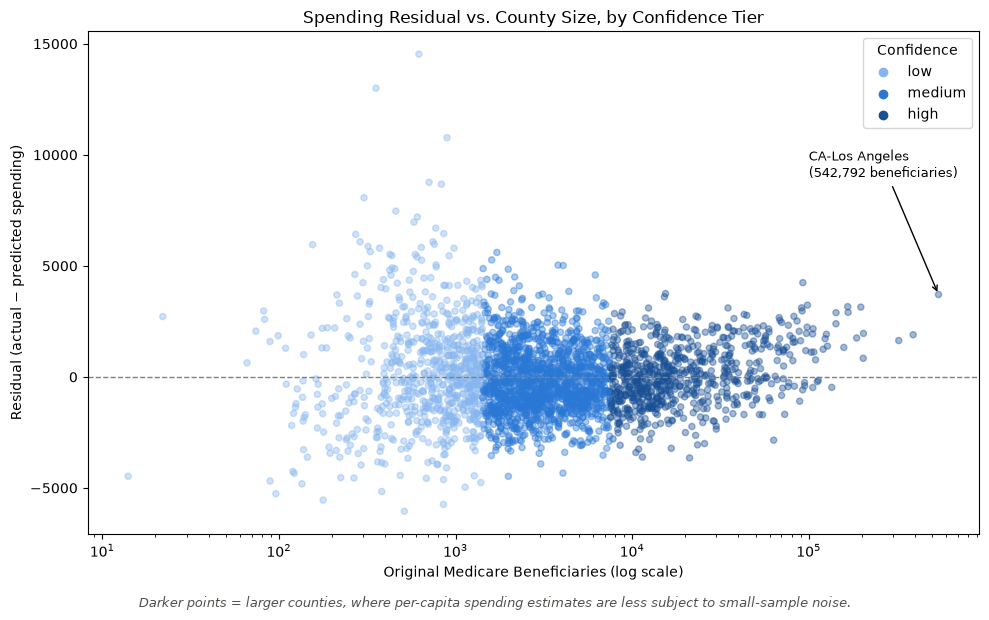

In [54]:

highlight_county = ['CA-Los Angeles']
highlight_rows = result[result['BENE_GEO_DESC'].isin(highlight_county)]  

import matplotlib.pyplot as plt

color_map = {'low': '#86b6ef', 'medium': '#2a78d6', 'high': '#184f95'}
colors = result['confidence'].map(color_map)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(result['BENES_OM_CNT'], result['residual'], c=colors, alpha=0.4, s=20)
ax.set_xscale('log')
ax.axhline(0, color='gray', linewidth=1, linestyle='--')
ax.set_xlabel('Original Medicare Beneficiaries (log scale)')
ax.set_ylabel('Residual (actual − predicted spending)')
ax.set_title('Spending Residual vs. County Size, by Confidence Tier')

for tier, color in color_map.items():
    ax.scatter([], [], c=color, label=tier)
ax.legend(title='Confidence')

label_positions = {
    'CA-Los Angeles':  (100000, 9000),       
}

for _, row in highlight_rows.iterrows():
    county_name = row['BENE_GEO_DESC']
    xytext_pos = label_positions[county_name]   

    ax.annotate(
        f"{row['BENE_GEO_DESC']}\n({row['BENES_OM_CNT']:,.0f} beneficiaries)",
        xy=(row['BENES_OM_CNT'], row['residual']),   
        xytext=xytext_pos,                            
        textcoords='data',
        fontsize=9,
        arrowprops=dict(arrowstyle='->', color='black', lw=1),
        ha='left'
    )
fig.text(
    0.5, -0.02,   
    "Darker points = larger counties, where per-capita spending estimates are less subject to small-sample noise.",
    ha='center', fontsize=9, style='italic', color='#52514e'
)
plt.tight_layout()
plt.show()

## Money Pit Lists

High Confidence Table

In [55]:
high_conf_table = high_conf.sort_values(by='residual', ascending=False).head(10) 
high_conf_table = high_conf_table.copy()
high_conf_table['residual_fmt'] = high_conf_table['residual'].apply(lambda x: f"${x:,.0f}")
high_conf_table['total_fmt'] = high_conf_table['total_spending_diff'].apply(lambda x: f"${x:,.0f}")

display_table = high_conf_table[['BENE_GEO_DESC', 'residual_fmt', 'total_fmt']]
display_table.columns = ['County', 'Per-Capita Residual', 'Total Dollar Impact']

print(display_table.to_markdown(index=False))

| County         | Per-Capita Residual   | Total Dollar Impact   |
|:---------------|:----------------------|:----------------------|
| FL-Miami-Dade  | $4,244                | $392,825,419          |
| TX-Wichita     | $3,752                | $58,002,567           |
| CA-Los Angeles | $3,708                | $2,012,492,829        |
| TX-Grayson     | $3,608                | $54,945,901           |
| FL-Broward     | $3,233                | $317,759,851          |
| FL-Palm Beach  | $3,164                | $525,812,887          |
| NY-Suffolk     | $3,143                | $619,490,605          |
| FL-Pinellas    | $3,111                | $283,177,182          |
| FL-Seminole    | $3,105                | $108,285,499          |
| LA-Bossier     | $3,101                | $38,395,954           |


Medium Confidence Table

In [56]:
med_conf_table = medium_conf.sort_values(by='residual', ascending=False).head(10)
med_conf_table = med_conf_table.copy()
med_conf_table['residual_fmt'] = med_conf_table['residual'].apply(lambda x: f"${x:,.0f}")
med_conf_table['total_fmt'] = med_conf_table['total_spending_diff'].apply(lambda x: f"${x:,.0f}")

display_table = med_conf_table[['BENE_GEO_DESC', 'residual_fmt', 'total_fmt']]
display_table.columns = ['County', 'Per-Capita Residual', 'Total Dollar Impact']

print(display_table.to_markdown(index=False))

| County        | Per-Capita Residual   | Total Dollar Impact   |
|:--------------|:----------------------|:----------------------|
| TX-Runnels    | $5,606                | $9,608,100            |
| LA-Bienville  | $5,268                | $8,440,134            |
| OK-Caddo      | $5,034                | $19,158,553           |
| LA-Washington | $5,012                | $20,400,222           |
| KS-Thomas     | $4,878                | $6,985,181            |
| LA-LaSalle    | $4,848                | $9,642,694            |
| OK-Bryan      | $4,591                | $28,374,807           |
| OK-Pawnee     | $4,498                | $9,725,148            |
| TX-Clay       | $4,484                | $7,551,144            |
| TX-Wilbarger  | $4,392                | $6,605,699            |


Low Confidence Table

In [57]:
low_conf_table = low_conf.sort_values(by='residual', ascending=False).head(10)
low_conf_table = low_conf_table.copy()
low_conf_table['residual_fmt'] = low_conf_table['residual'].apply(lambda x: f"${x:,.0f}")
low_conf_table['total_fmt'] = low_conf_table['total_spending_diff'].apply(lambda x: f"${x:,.0f}")

display_table = low_conf_table[['BENE_GEO_DESC', 'residual_fmt', 'total_fmt']]
display_table.columns = ['County', 'Per-Capita Residual', 'Total Dollar Impact']

print(display_table.to_markdown(index=False))

| County         | Per-Capita Residual   | Total Dollar Impact   |
|:---------------|:----------------------|:----------------------|
| GA-Miller      | $14,531               | $9,009,286            |
| KS-Hamilton    | $12,999               | $4,601,786            |
| OK-Greer       | $10,773               | $9,641,655            |
| KS-Ness        | $8,762                | $6,203,831            |
| KS-Stafford    | $8,678                | $7,220,016            |
| TX-Upton       | $8,068                | $2,444,549            |
| AK-North Slope | $7,463                | $3,425,470            |
| KS-Gove        | $7,201                | $4,377,971            |
| KS-Sheridan    | $6,968                | $4,048,687            |
| KS-Jewell      | $6,700                | $5,172,304            |


## Underserved Lists

High Confidence Table

In [58]:
high_conf_table = high_conf.sort_values(by='residual', ascending=True).head(10)
high_conf_table = high_conf_table.copy()
high_conf_table['residual_fmt'] = high_conf_table['residual'].apply(lambda x: f"${x:,.0f}")
high_conf_table['total_fmt'] = high_conf_table['total_spending_diff'].apply(lambda x: f"${x:,.0f}")

display_table = high_conf_table[['BENE_GEO_DESC', 'residual_fmt', 'total_fmt']]
display_table.columns = ['County', 'Per-Capita Residual', 'Total Dollar Impact']

print(display_table.to_markdown(index=False))

| County                  | Per-Capita Residual   | Total Dollar Impact   |
|:------------------------|:----------------------|:----------------------|
| HI-Hawaii               | $-3,647               | $-77,119,000          |
| AK-Fairbanks North Star | $-3,608               | $-41,251,715          |
| OR-Klamath              | $-3,406               | $-35,758,094          |
| HI-Maui                 | $-3,250               | $-35,357,505          |
| OR-Douglas              | $-3,214               | $-53,513,250          |
| WA-Stevens              | $-3,079               | $-26,331,093          |
| WA-Yakima               | $-3,060               | $-71,779,853          |
| CA-Humboldt             | $-3,002               | $-77,089,835          |
| HI-Honolulu             | $-2,849               | $-180,310,057         |
| CA-Siskiyou             | $-2,822               | $-35,398,818          |


Medium Confidence Table

In [59]:
med_conf_table = medium_conf.sort_values(by='residual', ascending=True).head(10)
med_conf_table = med_conf_table.copy()
med_conf_table['residual_fmt'] = med_conf_table['residual'].apply(lambda x: f"${x:,.0f}")
med_conf_table['total_fmt'] = med_conf_table['total_spending_diff'].apply(lambda x: f"${x:,.0f}")

display_table = med_conf_table[['BENE_GEO_DESC', 'residual_fmt', 'total_fmt']]
display_table.columns = ['County', 'Per-Capita Residual', 'Total Dollar Impact']

print(display_table.to_markdown(index=False))

| County        | Per-Capita Residual   | Total Dollar Impact   |
|:--------------|:----------------------|:----------------------|
| ID-Boundary   | $-4,476               | $-8,910,798           |
| NM-Rio Arriba | $-4,331               | $-17,579,141          |
| AZ-Santa Cruz | $-3,916               | $-11,885,412          |
| MT-Glacier    | $-3,542               | $-5,649,907           |
| HI-Kauai      | $-3,526               | $-24,130,364          |
| NM-San Miguel | $-3,447               | $-10,250,265          |
| OR-Wasco      | $-3,397               | $-14,103,612          |
| NM-Colfax     | $-3,336               | $-6,848,710           |
| AR-Phillips   | $-3,309               | $-5,585,394           |
| WV-Monroe     | $-3,233               | $-6,420,095           |


Low Confidence Table

In [60]:
low_conf_table = low_conf.sort_values(by='residual', ascending=True).head(10)
low_conf_table = low_conf_table.copy()
low_conf_table['residual_fmt'] = low_conf_table['residual'].apply(lambda x: f"${x:,.0f}")
low_conf_table['total_fmt'] = low_conf_table['total_spending_diff'].apply(lambda x: f"${x:,.0f}")

display_table = low_conf_table[['BENE_GEO_DESC', 'residual_fmt', 'total_fmt']]
display_table.columns = ['County', 'Per-Capita Residual', 'Total Dollar Impact']

print(display_table.to_markdown(index=False))

| County          | Per-Capita Residual   | Total Dollar Impact   |
|:----------------|:----------------------|:----------------------|
| AK-Kusilvak     | $-6,046               | $-3,101,849           |
| TX-Presidio     | $-5,741               | $-4,902,635           |
| AK-Copper River | $-5,547               | $-987,368             |
| AK-Yakutat      | $-5,259               | $-504,909             |
| MT-Judith Basin | $-5,161               | $-1,971,410           |
| NM-Torrance     | $-4,965               | $-5,625,387           |
| MS-Issaquena    | $-4,813               | $-649,801             |
| AK-Bethel       | $-4,757               | $-6,611,620           |
| NE-Arthur       | $-4,687               | $-417,121             |
| CO-Saguache     | $-4,623               | $-3,952,626           |


## Summary

Ranked by total dollar impact, Los Angeles County is the clearest money pit in the dataset (~$2.0B above what its diabetes prevalence predicts), followed by Cook (IL), Suffolk (NY), Maricopa (AZ), Palm Beach (FL), and Miami-Dade (FL). Note that ranking by per-capita residual alone tells a different story: Miami-Dade actually overspends more per beneficiary than LA does, but LA's population size makes its aggregate impact far larger. This is why total dollar impact, not per-capita residual, drives this list.

On the underserved side, the high-confidence tier surfaces a geographic pattern worth a second look: Hawaii, Fairbanks North Star (AK), and several Pacific Northwest counties (Klamath, Douglas, Stevens, Yakima) all spend well below what their diabetes prevalence would predict. This is a signal worth investigating for access or utilization gaps rather than genuinely lower need.

All findings above draw from the high-confidence tier (≥7,506 beneficiaries), where per-capita spending estimates are least subject to small-sample noise. Money pit and underserved counties flagged in the medium and low tiers should be read as directional, not conclusive, given the smaller sample sizes behind them.